In [ ]:
USER = "varom"

import ROOT
import pandas as pd
import numpy as np

#filename = "/data/at3/common/EWK2L3L_ANA-SUSY-2024-02/FFntuples/RUN2/SIGNAL/C1N2_WZ_2L_569622_mc20a_fastsim.root"
filename = "/data/at3/common/EWK2L3L_ANA-SUSY-2024-02/FFntuples/RUN2_v2/C1N2_WZ_2L_569622_mc20a_fastsim.root"

In [2]:
import uproot
import awkward as ak

# ROOT TO PANDAS BUT USING UPROOT (FLATTENS THE DATA IN CASE THERE ARE MULTIPLE CANDIDATES)

def convert_ROOT_to_pd(filename,cols):
    #Convierte un ROOT file a un DataFrame de pandas de manera segura,incluso si contiene columnas vectoriales.
    
    with uproot.open(filename) as f:
        tree = f["analysis"]

        if cols == None:
            all_columns = tree.keys()
        else:
            all_columns = cols

        arr = tree.arrays(all_columns, library="ak")
        df = ak.to_dataframe(arr).copy()
    return df


df_test = convert_ROOT_to_pd(filename,None)

/nfs/pic.es/user/v/varom/miniforge3/envs/hep311/lib/python3.11/site-packages/awkward/operations/ak_to_dataframe.py:168: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1 = df1.reset_index(level=df1_extra)
/nfs/pic.es/user/v/varom/miniforge3/envs/hep311/lib/python3.11/site-packages/awkward/operations/ak_to_dataframe.py:168: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df1 = df1.reset_index(level=df1_extra)


In [3]:
def search_cols(df,word):
    pid_columns = [col for col in df.columns if word in col]

    return pid_columns

In [4]:
for col in df_test.columns:
    print(col)
    
#df_test.columns

L2_RJ_CM_pt_NOSYS
L2_RJ_ISR_pt_NOSYS
L2_RJ_I_pt_NOSYS
L2_RJ_MTS_NOSYS
L2_RJ_R_ISR_NOSYS
L2_RJ_dPhi_ISRI_NOSYS
L2_RJ_jet_n_ISR_NOSYS
L2_RJ_jet_n_V_NOSYS
L2_R_METJets_NOSYS
L2_costhetastar_NOSYS
L2_dPhi_METj_NOSYS
L2_dPhi_METl_NOSYS
L2_dPhi_METll_NOSYS
L2_dPhi_ll_NOSYS
L2_dR_ll_NOSYS
L2_el_select_baselineVeryLooseID_NOSYS
L2_el_select_baseline_NOSYS
L2_el_select_impactCuts_NOSYS
L2_el_select_looseDNNIDNonIso_NOSYS
L2_el_select_looseDNNIDlooseIso_NOSYS
L2_el_select_looseDNNIDtightIso_NOSYS
L2_el_select_looseIDlooseIso_NOSYS
L2_el_select_looseIDtightIso_NOSYS
L2_el_select_mediumDNNIDNonIso_NOSYS
L2_el_select_mediumDNNIDlooseIso_NOSYS
L2_el_select_mediumDNNIDtightIso_NOSYS
L2_el_select_passesORbaseline_NOSYS
L2_el_select_passesORsignal_NOSYS
L2_el_select_passesORslep_NOSYS
L2_el_select_signalVeryLooseID_NOSYS
L2_el_select_signal_NOSYS
L2_el_select_slep_signal_NOSYS
L2_el_select_tightDNNIDNonIso_NOSYS
L2_el_select_tightDNNIDlooseIso_NOSYS
L2_el_select_tightDNNIDtightIso_NOSYS
L2_el_select_ti

In [5]:
def remove_cols(df,dictionary):
    # Removes all the columns that have a word inside the dictionary.

    words = dictionary.keys()
    df_new = df.drop(columns=[col for col in df.columns if any(word in col for word in words)])

    return df_new

# Voy a probar a plotear alguna variable

In [6]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import os 
import seaborn as sns
import pandas as pd
import numpy as np

# -------------------------------- PLOT HISTOGRAM ----------------------------------------------------------------------

def plot_hist(df, column_name, title, x_min, x_max, ax, lin_log, epsilon,use_latex, wbins_dict=None, units_dict=None):

    # df: dataframe
    # column_name: name of the variable that we want to plot
    # title: title
    # x_min: minimum plotting range
    # x_max: maximum plotting range
    # ax
    # lin_log: linear or logarithmic plotting, ie log(data), not logarithmic axis
    # epsilon: very small value that avoids divergences on the plotting
    # wbins_dict: bin width
    # units_dict: units of the variable
    # use_latex: True for latex, false for non-latex
    
    if column_name not in df.columns:
        print(f"La columna '{column_name}' no existe en el DataFrame.")
        return

    bin_width = wbins_dict[column_name] if (wbins_dict and column_name in wbins_dict) else 0.1
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)

    groups = [
            ((df.BKGCAT_BIN==0), "Background", "skyblue"),
            ((df.BKGCAT_BIN==1), "Signal", "salmon"),
        ]

    for mask, label, color in groups:
        data = df.loc[mask, column_name]
        if len(data) == 0:
            continue
        if lin_log == 'log':
            data = data[data >= 0].copy()
            data = data.replace(0, epsilon)   # sustituir únicamente los ceros
            data = np.log10(data)
            
        ax.hist(data, bins=bin_edges, histtype="stepfilled", alpha=0.5, density=True, edgecolor=color,
                linewidth=3, label=label, color=color)

    ax.set_xlim(x_min, x_max)

    # --- Units ---
    units = units_dict.get(column_name) if units_dict else None
    bw_str = str(int(bin_width)) if bin_width == int(bin_width) else f"{bin_width:g}"

    # X label
    if use_latex == True:
        x_base = column_name.replace('_', r'\_')
    else:
        x_base = column_name
        
    x_label = rf"{x_base} $[{units}]$" if units else x_base

    # Y label
    y_label = rf"Norm. events / ${bw_str}\;{units}$" if units else rf"Norm. events / ${bw_str}$"

    ax.set_xlabel(x_label, loc="center")
    ax.set_ylabel(y_label, loc="top")
    ax.legend(fontsize=18, frameon=True)

# ------------ PLOT MULTIPLE HISTOGRAMS AT ONCE -----------------------------------------------------------------------

def subplot_hist(df, variables, title, x_ranges, lin_log_dict, epsilon, use_latex,wbins_dict=None, units_dict=None):
    
    # df: dataframe
    # variables: dictionary with the variables that we want to plot
    # title: title
    # x_ranges: dictionary of plotting ranges
    # lin_log: dictionary that indicates linear or logarithmic plotting, ie log(data), not logarithmic axis
    # epsilon: very small value that avoids divergences on the plotting
    # wbins_dict: bin width
    # units_dict: units of the variable
    # use_latex: True for latex, false for non-latex
    
    N = len(variables)
    ncols = 3
    nrows = (N + ncols - 1) // ncols

    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "figure.figsize": (8, 20),
        "figure.dpi": 150,
        "text.usetex": use_latex #Cambiar a true si me apetece
    })

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    fig.suptitle(title, fontsize=24)
    axes = axes.flatten()

    for ax, var in zip(axes, variables):
        if var not in x_ranges:
            print(f"Rango no definido para {var}, se salta")
            continue
        lin_log = lin_log_dict.get(var, 'lin') # Searches inside the lin_log dictionary. If 'None', fill with 'lin'
        x_min, x_max = x_ranges[var]
        plot_hist(df=df, column_name=var, title=title, x_min=x_min, x_max=x_max,
                     ax=ax, lin_log=lin_log, epsilon=epsilon, use_latex=use_latex,wbins_dict=wbins_dict, units_dict=units_dict)

    for ax in axes[N:]:
        ax.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    return fig, axes

# ------------------------- FUNCTION TO SAVE PLOTS -------------------------------------

import os

def save_plot(USER, directory, fig, pdfname):

    # USER
    # directory: directory into which the pdf file is going
    # fig: figure
    # pdfname
    
    if USER != "varom":
        return

    os.makedirs(directory, exist_ok=True)

    filename = os.path.join(directory, f"{pdfname}.pdf")
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)

    

# Add a column to identify that these data are MonteCarlo (Signal)

In [7]:
df_test['BKGCAT_BIN'] = 1

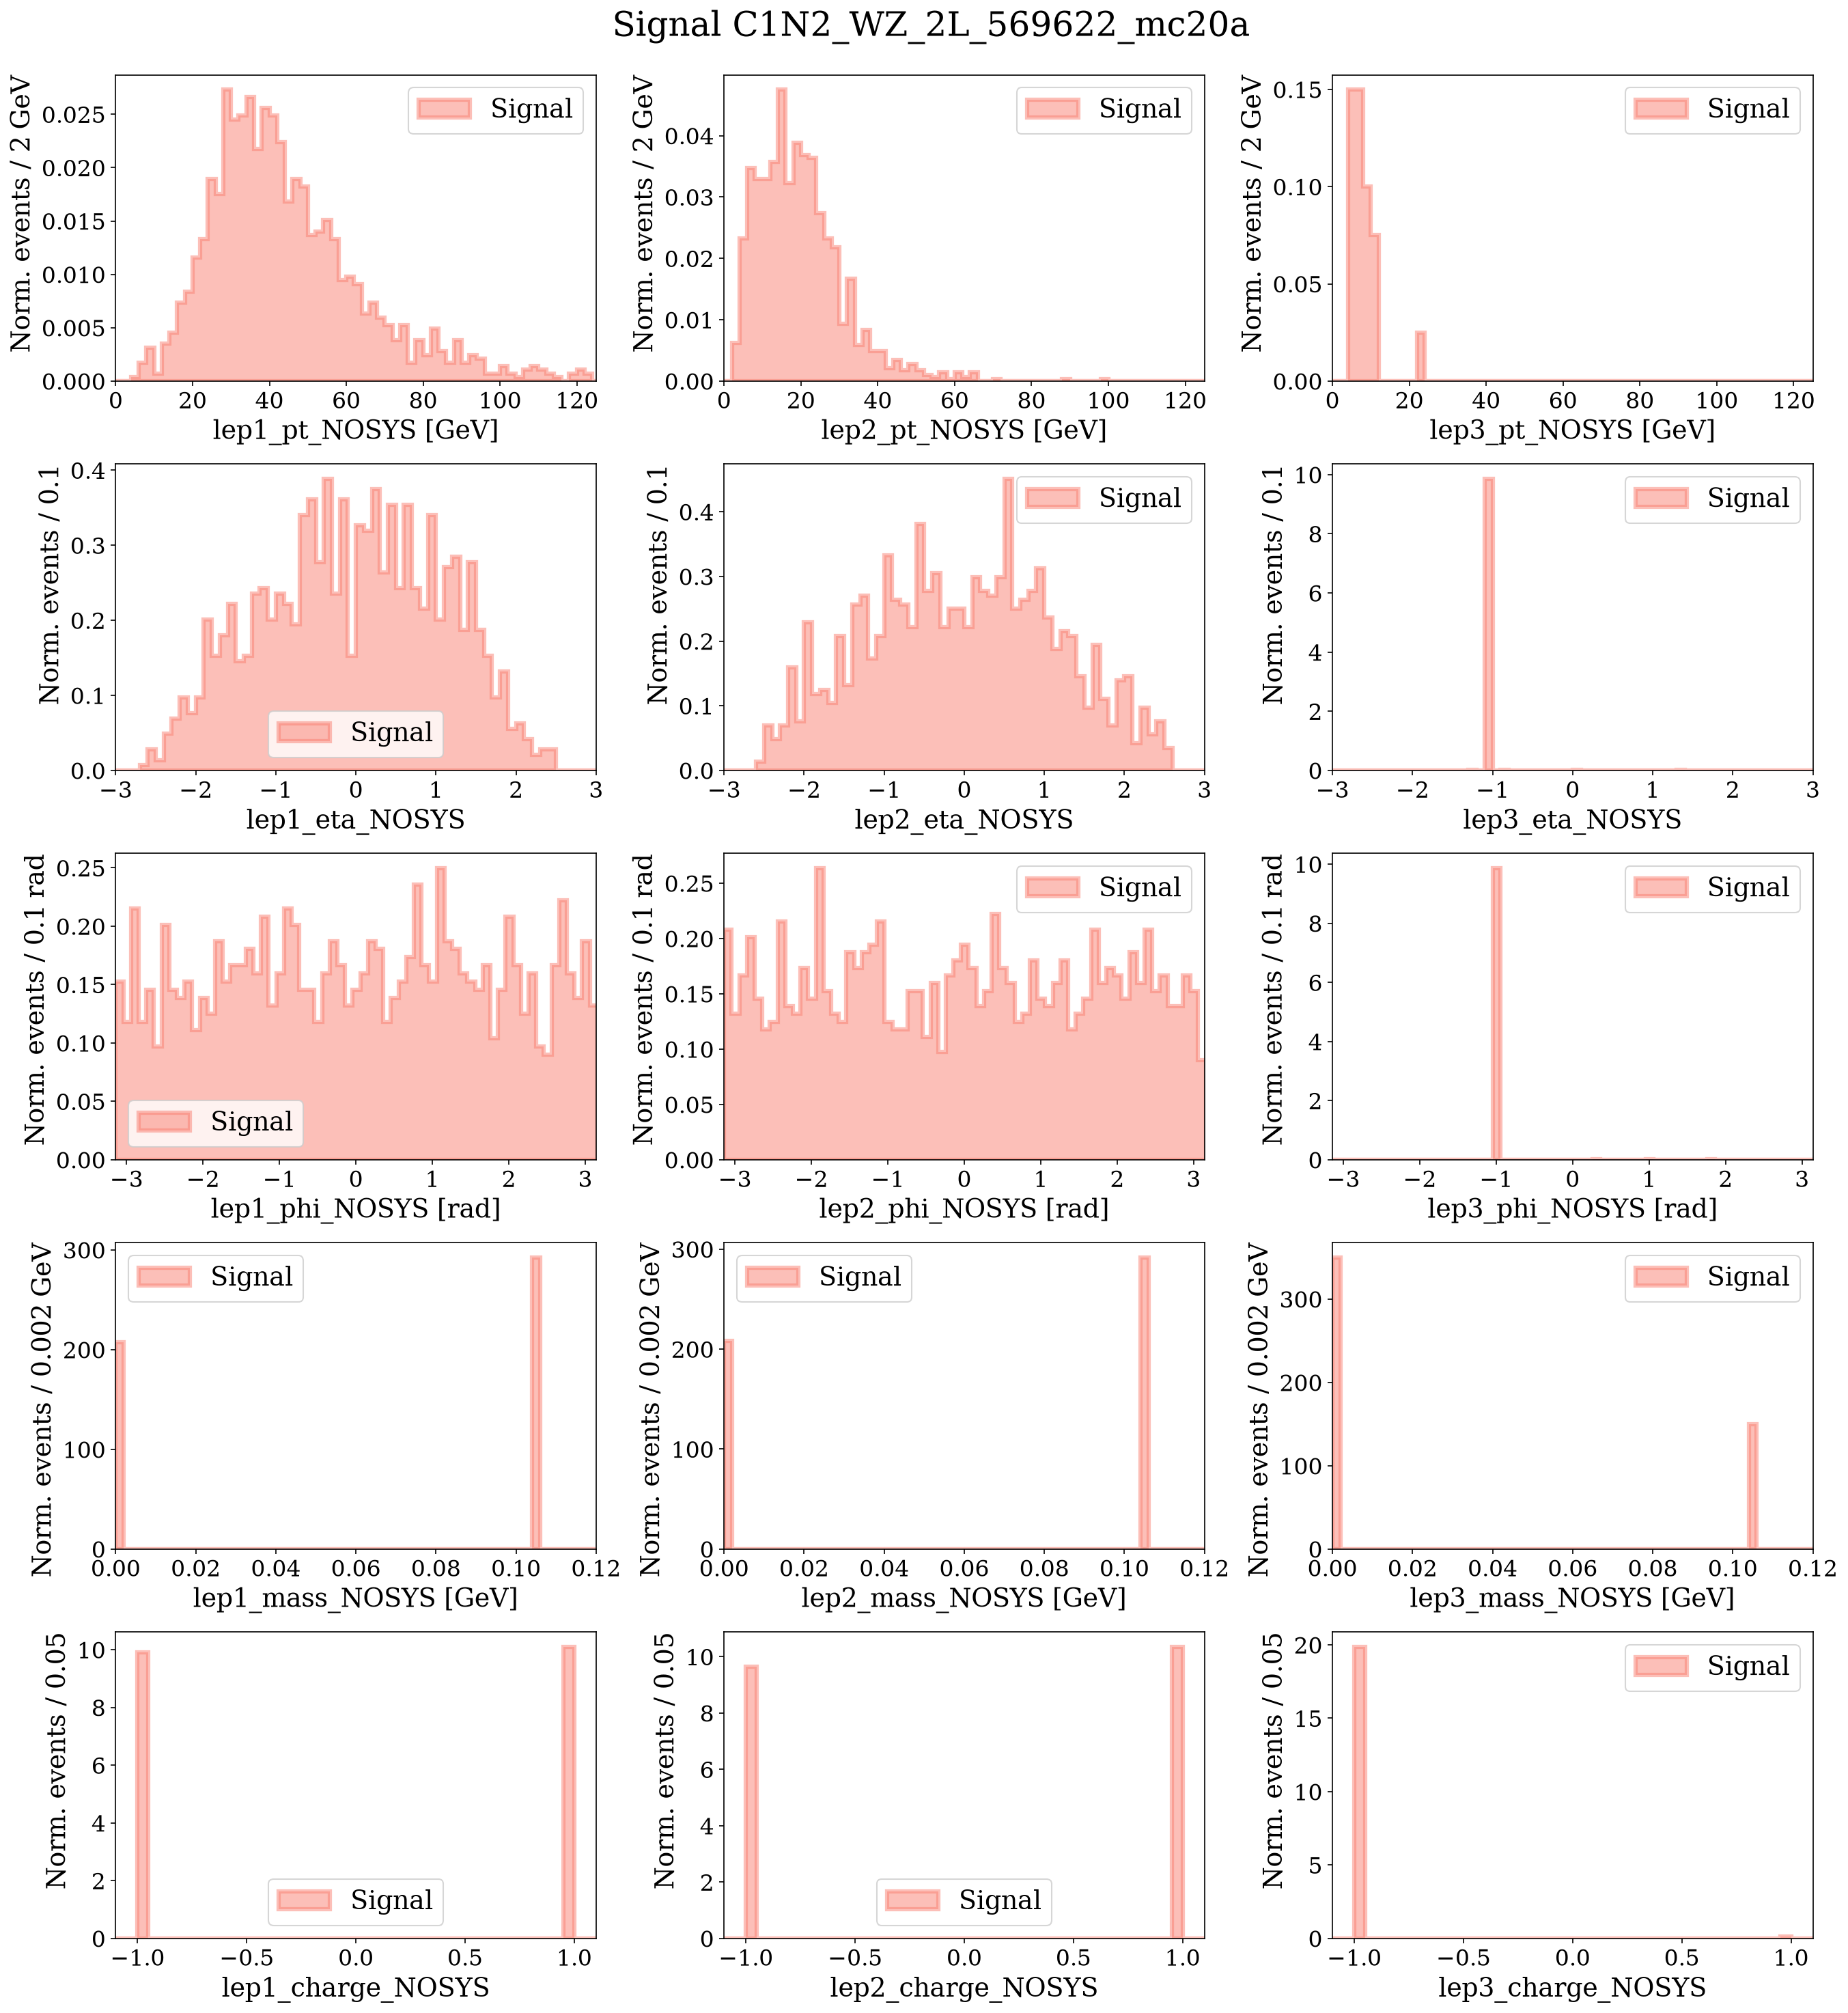

In [8]:
variables = ['lep1_pt_NOSYS','lep2_pt_NOSYS','lep3_pt_NOSYS','lep1_eta_NOSYS','lep2_eta_NOSYS','lep3_eta_NOSYS','lep1_phi_NOSYS','lep2_phi_NOSYS',
'lep3_phi_NOSYS','lep1_mass_NOSYS','lep2_mass_NOSYS','lep3_mass_NOSYS','lep1_charge_NOSYS','lep2_charge_NOSYS','lep3_charge_NOSYS']

lin_log_dict = {
    'lep1_pt_NOSYS': 'lin',
    'lep2_pt_NOSYS': 'lin',
    'lep3_pt_NOSYS': 'lin',
    'lep1_eta_NOSYS': 'lin',
    'lep2_eta_NOSYS':'lin',
    'lep3_eta_NOSYS':'lin',
    'lep1_phi_NOSYS':'lin',
    'lep2_phi_NOSYS':'lin',
    'lep3_phi_NOSYS':'lin',
    'lep1_mass_NOSYS':'lin',
    'lep2_mass_NOSYS':'lin',
    'lep3_mass_NOSYS':'lin',
    'lep1_charge_NOSYS':'lin',
    'lep2_charge_NOSYS':'lin',
    'lep3_charge_NOSYS':'lin'
}

x_ranges = {
    'lep1_pt_NOSYS': (0,125),
    'lep2_pt_NOSYS': (0,125),
    'lep3_pt_NOSYS': (0,125),
    'lep1_eta_NOSYS':(-3,3),
    'lep2_eta_NOSYS':(-3,3),
    'lep3_eta_NOSYS':(-3,3),
    'lep1_phi_NOSYS':(-np.pi,np.pi),
    'lep2_phi_NOSYS':(-np.pi,np.pi),
    'lep3_phi_NOSYS':(-np.pi,np.pi),
    'lep1_mass_NOSYS':(0,0.12),
    'lep2_mass_NOSYS':(0,0.12),
    'lep3_mass_NOSYS':(0,0.12),
    'lep1_charge_NOSYS':(-1.1,1.1),
    'lep2_charge_NOSYS':(-1.1,1.1),
    'lep3_charge_NOSYS':(-1.1,1.1)
}


wbins_dict = {
    'lep1_pt_NOSYS': 2,
    'lep2_pt_NOSYS': 2,
    'lep3_pt_NOSYS': 2,
    'lep1_eta_NOSYS':0.1,
    'lep2_eta_NOSYS':0.1,
    'lep3_eta_NOSYS':0.1,
    'lep1_phi_NOSYS':0.1,
    'lep2_phi_NOSYS':0.1,
    'lep3_phi_NOSYS':0.1,
    'lep1_mass_NOSYS':0.002,
    'lep2_mass_NOSYS':0.002,
    'lep3_mass_NOSYS':0.002,
    'lep1_charge_NOSYS':0.05,
    'lep2_charge_NOSYS':0.05,
    'lep3_charge_NOSYS':0.05
}


units_dict = {
    'lep1_pt_NOSYS': r'\mathrm{GeV}',
    'lep2_pt_NOSYS': r'\mathrm{GeV}',
    'lep3_pt_NOSYS': r'\mathrm{GeV}',
    'lep1_eta_NOSYS': None,
    'lep2_eta_NOSYS': None,
    'lep3_eta_NOSYS': None,
    'lep1_phi_NOSYS': r'\mathrm{rad}',
    'lep2_phi_NOSYS': r'\mathrm{rad}',
    'lep3_phi_NOSYS': r'\mathrm{rad}',
    'lep1_mass_NOSYS': r'\mathrm{GeV}',
    'lep2_mass_NOSYS': r'\mathrm{GeV}',
    'lep3_mass_NOSYS': r'\mathrm{GeV}',
    'lep1_charge_NOSYS':None,
    'lep2_charge_NOSYS':None,
    'lep3_charge_NOSYS':None
}


fig,axes = subplot_hist(df=df_test,variables=variables,title='Signal C1N2_WZ_2L_569622_mc20a',x_ranges=x_ranges,lin_log_dict=lin_log_dict,
                       epsilon=10e-15,use_latex=False,wbins_dict=wbins_dict,units_dict=units_dict)


save_plot(USER='varom',directory='/nfs/pic.es/user/v/varom/SusyAD_IFAE/Plots',fig=fig,pdfname='09_07_26_A_FeaturePlots')

# Let's try and separate between muon and electron

In [9]:
# Ver qué valores toma flavor cuando el leptón pasa selección de electrón baseline
print(df_test.loc[df_test["lep1_el_select_baseline_NOSYS"] == 1, "lep1_flavor_NOSYS"].unique())

# Ver qué valores toma flavor cuando el leptón pasa selección de muón baseline
print(df_test.loc[df_test["lep1_mu_select_baseline_NOSYS"] == 1, "lep1_flavor_NOSYS"].unique())

[11]
[13]


# Plot differentiating between muon and electron

In [10]:
# ----------------- MAKING THE MAIN PLOT ---------------------------------------------------

def plot_hist_elORmu(df, column_name, lepton_number, title, x_min, x_max, ax, lin_log, epsilon,use_latex, wbins_dict=None, units_dict=None):

    # df: dataframe
    # column_name: name of the variable that we want to plot
    # lepton_number: 1, 2 or 3
    # title: title
    # x_min: minimum plotting range
    # x_max: maximum plotting range
    # ax
    # lin_log: linear or logarithmic plotting, ie log(data), not logarithmic axis
    # epsilon: very small value that avoids divergences on the plotting
    # wbins_dict: bin width
    # units_dict: units of the variable
    # use_latex: True for latex, false for non-latex
    
    if column_name not in df.columns:
        print(f"La columna '{column_name}' no existe en el DataFrame.")
        return

    bin_width = wbins_dict[column_name] if (wbins_dict and column_name in wbins_dict) else 0.1
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    
    flavor_col = f"lep{lepton_number}_flavor_NOSYS"
    if flavor_col not in df.columns:
        print("Wrong lepton number introduced.")
        return

    groups = [
        ((df.BKGCAT_BIN == 1) & (df[flavor_col] == 11), "Signal electron", "skyblue"),
        ((df.BKGCAT_BIN == 1) & (df[flavor_col] == 13), "Signal muon", "salmon"),
    ]

    for mask, label, color in groups:
        data = df.loc[mask, column_name]
        if len(data) == 0:
            continue
        if lin_log == 'log':
            data = data[data >= 0].copy()
            data = data.replace(0, epsilon)   # sustituir únicamente los ceros
            data = np.log10(data)
            
        ax.hist(data, bins=bin_edges, histtype="stepfilled", alpha=0.5, density=True, edgecolor=color,
                linewidth=3, label=label, color=color)

    ax.set_xlim(x_min, x_max)

    # --- Units ---
    units = units_dict.get(column_name) if units_dict else None
    bw_str = str(int(bin_width)) if bin_width == int(bin_width) else f"{bin_width:g}"

    # X label
    if use_latex == True:
        x_base = column_name.replace('_', r'\_')
    else:
        x_base = column_name
        
    x_label = rf"{x_base} $[{units}]$" if units else x_base

    # Y label
    y_label = rf"Norm. events / ${bw_str}\;{units}$" if units else rf"Norm. events / ${bw_str}$"

    ax.set_xlabel(x_label, loc="center")
    ax.set_ylabel(y_label, loc="top")
    ax.legend(fontsize=18, frameon=True)

# -------------------------- MAKING THE SUBPLOTS ------------------------------------------------------------------------

def subplot_hist_elORmu(df, variables, title, x_ranges, lin_log_dict, epsilon, use_latex,wbins_dict=None, units_dict=None):
    
    # df: dataframe
    # variables: dictionary with the variables that we want to plot
    # title: title
    # x_ranges: dictionary of plotting ranges
    # lin_log: dictionary that indicates linear or logarithmic plotting, ie log(data), not logarithmic axis
    # epsilon: very small value that avoids divergences on the plotting
    # wbins_dict: bin width
    # units_dict: units of the variable
    # use_latex: True for latex, false for non-latex
    
    N = len(variables)
    ncols = 3
    nrows = (N + ncols - 1) // ncols

    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "mathtext.fontset": "dejavuserif",
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "figure.figsize": (8, 20),
        "figure.dpi": 150,
        "text.usetex": use_latex #Cambiar a true si me apetece
    })

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    fig.suptitle(title, fontsize=24)
    axes = axes.flatten()
    lepton_numb = [1,2,3] * nrows

    for ax, var, lept_num in zip(axes, variables, lepton_numb):
        if var not in x_ranges:
            print(f"Rango no definido para {var}, se salta")
            continue
        lin_log = lin_log_dict.get(var, 'lin') # Searches inside the lin_log dictionary. If 'None', fill with 'lin'
        x_min, x_max = x_ranges[var]
        plot_hist_elORmu(df=df, column_name=var,lepton_number=lept_num, title=title, x_min=x_min, x_max=x_max,
                     ax=ax, lin_log=lin_log, epsilon=epsilon, use_latex=use_latex,wbins_dict=wbins_dict, units_dict=units_dict)

    for ax in axes[N:]:
        ax.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    return fig, axes

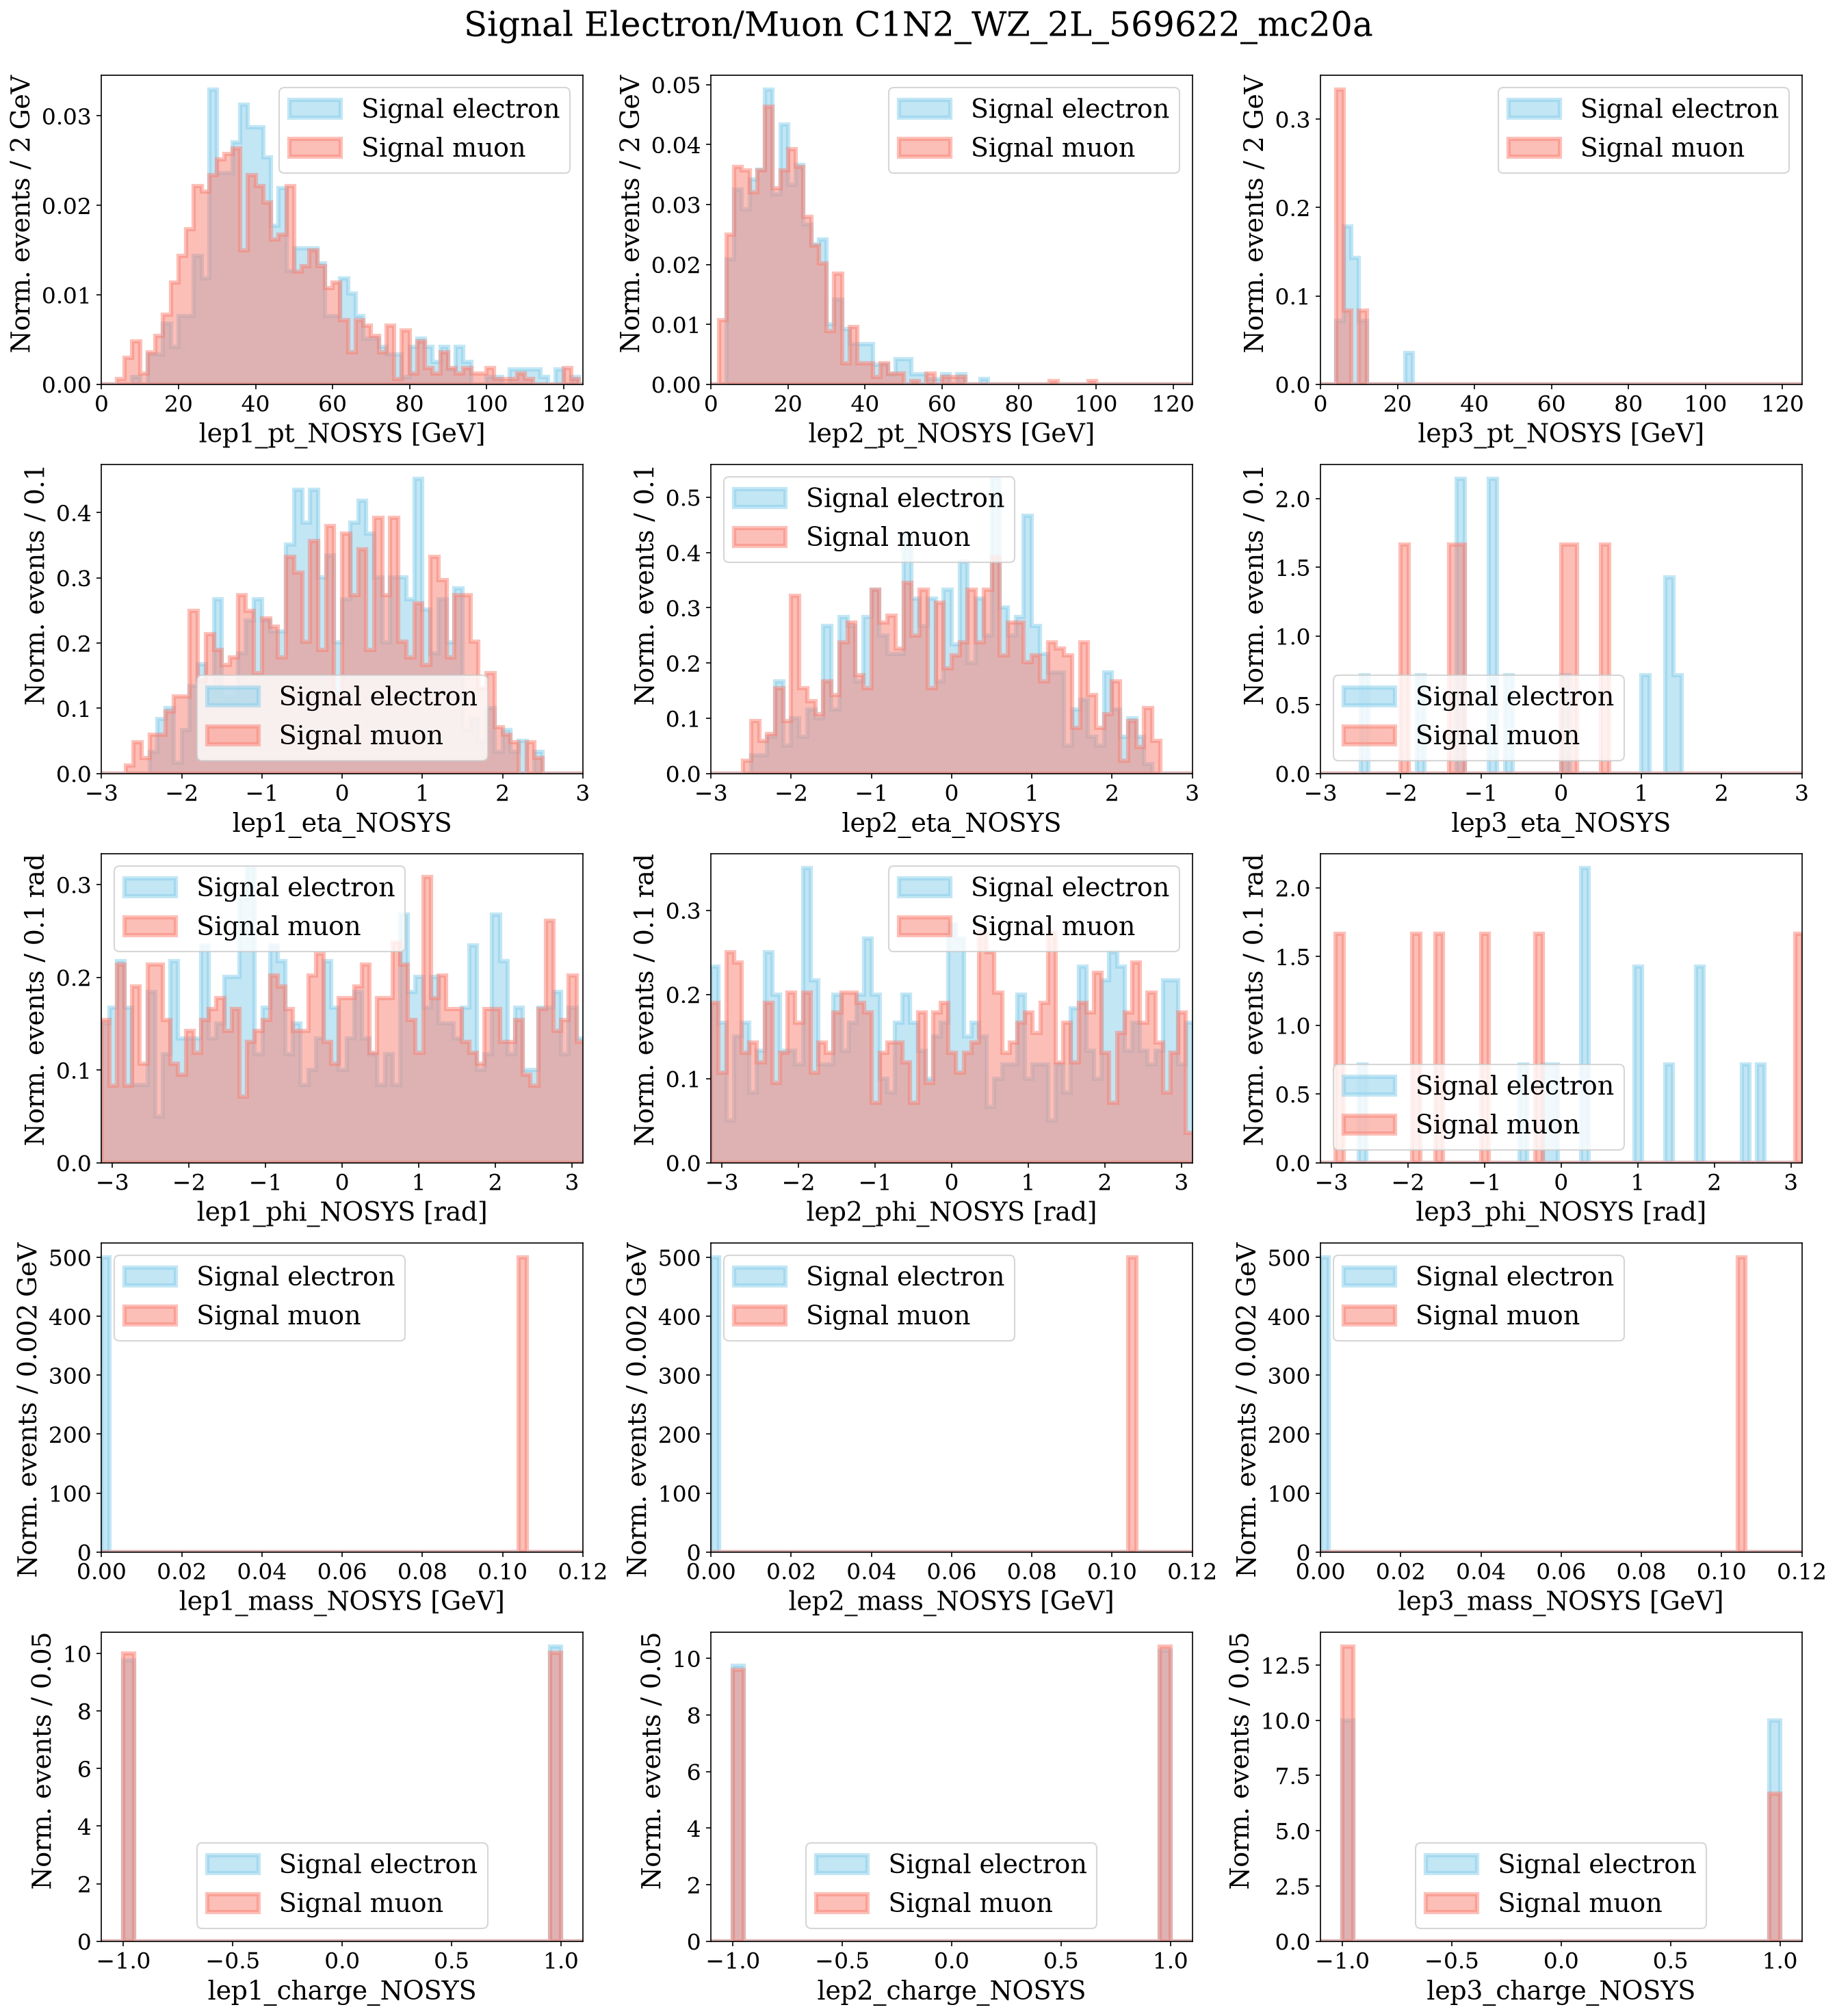

In [11]:
fig2,axes2 = subplot_hist_elORmu(df=df_test,variables=variables,title='Signal Electron/Muon C1N2_WZ_2L_569622_mc20a',x_ranges=x_ranges,lin_log_dict=lin_log_dict,
                       epsilon=10e-15,use_latex=False,wbins_dict=wbins_dict,units_dict=units_dict)

save_plot(USER='varom',directory='/nfs/pic.es/user/v/varom/SusyAD_IFAE/Plots',fig=fig2,pdfname='09_07_26_B_FeaturePlots_ElMu')